[CFG] Device : cuda
[CFG] Model  : convnext_base.fb_in22k_ft_in1k
[CFG] Image  : 224×224

[Dataset] Total samples found: 2176

[Class Distribution]
  CLASS A  (0)  →   1114  ██████████████████████████████
  CLASS B  (1)  →    593  ████████████████
  CLASS C  (2)  →    469  ████████████
  Total                 →   2176


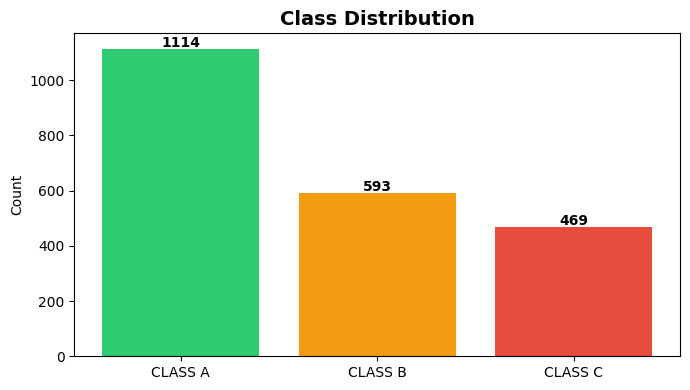


[Split]  Train: 1740  |  Val: 436

[DataLoader]  Train batches: 54  |  Val batches: 7


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

[Model] Backbone FROZEN (head-only warm-up)
[Model] Total params    : 88,094,851
[Model] Trainable params: 528,387

[Loss] Class weights: {'CLASS A': np.float64(0.571), 'CLASS B': np.float64(1.073), 'CLASS C': np.float64(1.356)}

══════════════════════════════════════════════════════════════════════
  TRAINING START
══════════════════════════════════════════════════════════════════════
  Epoch [  1/50] | Tr Loss: 0.4453  Tr Acc: 0.4306 | Val Loss: 0.3197  Val Acc: 0.4128 | Val F1(w): 0.3025  LR: 2.45e-05
  ✔ Best model saved  (F1=0.3025)
  Epoch [  2/50] | Tr Loss: 0.3144  Tr Acc: 0.6071 | Val Loss: 0.1935  Val Acc: 0.6972 | Val F1(w): 0.7106  LR: 5.99e-05
  ✔ Best model saved  (F1=0.7106)
  Epoch [  3/50] | Tr Loss: 0.2256  Tr Acc: 0.7164 | Val Loss: 0.1381  Val Acc: 0.7982 | Val F1(w): 0.8060  LR: 1.12e-04
  ✔ Best model saved  (F1=0.8060)
  Epoch [  4/50] | Tr Loss: 0.1942  Tr Acc: 0.7546 | Val Loss: 0.1348  Val Acc: 0.7729 | Val F1(w): 0.7848  LR: 1.72e-04
  Epoch [  5/50] | Tr Los

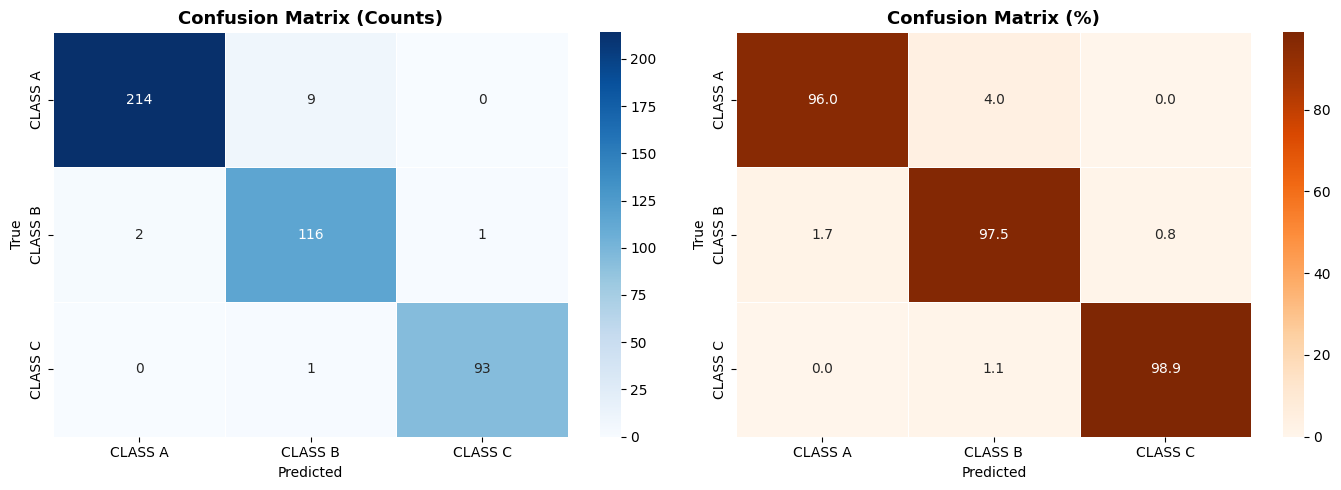

[Plot] Confusion matrix saved → /kaggle/working/confusion_matrix.png


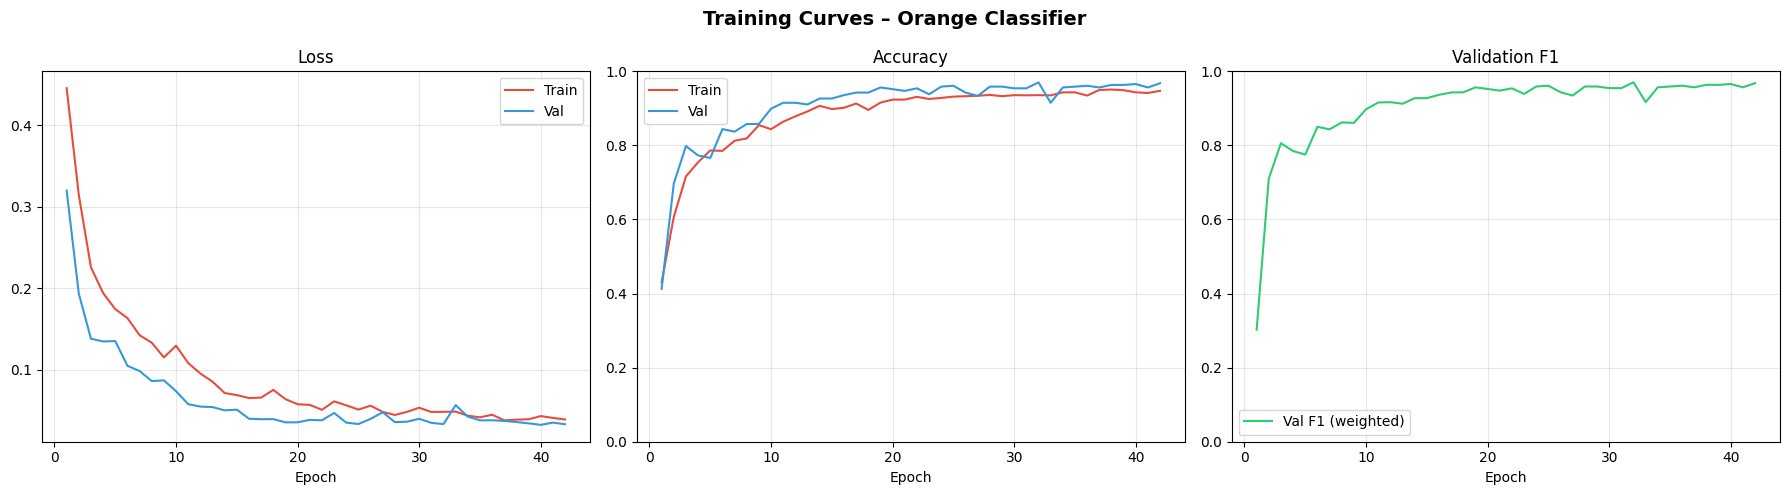

[Plot] Training curves saved → /kaggle/working/training_curves.png

╔══════════════════════════════════════════════════════════╗
║           PIPELINE COMPLETE  –  SUMMARY                 ║
╠══════════════════════════════════════════════════════════╣
║  Architecture  : ConvNeXt-Base (ImageNet-22k pretrain)  ║
║  Loss          : Focal + Label Smoothing + Class Weights ║
║  Sampler       : WeightedRandomSampler (imbalance)       ║
║  Schedule      : OneCycleLR + Warm-up freeze strategy   ║
║  AMP           : Enabled                              ║
╠══════════════════════════════════════════════════════════╣
║  Best Epoch    : 32                                    ║
║  Val Accuracy  : 0.9702                                ║
║  Val F1 (w)    : 0.9704                                ║
╠══════════════════════════════════════════════════════════╣
║  Saved model   : best_orange_model.pth                  ║
║  Plots         : confusion_matrix.png                   ║
║                  training_cur

In [3]:
"""
═══════════════════════════════════════════════════════════════════════════════
    ORANGE QUALITY CLASSIFICATION PIPELINE  |  CLASS A / B / C
    PyTorch · timm · Albumentations · AMP · Focal Loss · ConvNeXt
    Author: Production-Grade DL Pipeline
═══════════════════════════════════════════════════════════════════════════════
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0. DEPENDENCIES
# ─────────────────────────────────────────────────────────────────────────────
import os
import random
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import timm

# ─────────────────────────────────────────────────────────────────────────────
# 1. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# ─────────────────────────────────────────────────────────────────────────────
# 2. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────
    DATA_ROOT = Path("/kaggle/input/datasets/fatmaeissa/new-orange-dataset/Orange DataSet")
    SAVE_DIR  = Path("/kaggle/working")
    MODEL_PATH = SAVE_DIR / "best_orange_model.pth"

    # ── Classes ────────────────────────────────────────────────────────────
    CLASSES   = ["CLASS A", "CLASS B", "CLASS C"]
    NUM_CLASSES = 3
    CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
    IDX2CLASS = {i: c for i, c in enumerate(CLASSES)}

    # ── Model ──────────────────────────────────────────────────────────────
    MODEL_NAME  = "convnext_base.fb_in22k_ft_in1k"   # strong ImageNet-22k pretrain
    IMAGE_SIZE  = 224
    DROPOUT     = 0.35

    # ── Training ───────────────────────────────────────────────────────────
    EPOCHS       = 50
    BATCH_SIZE   = 32
    NUM_WORKERS  = 4
    VAL_SPLIT    = 0.20
    LR           = 3e-4
    MIN_LR       = 1e-6
    WEIGHT_DECAY = 1e-4

    # ── Loss ───────────────────────────────────────────────────────────────
    LABEL_SMOOTHING = 0.10
    FOCAL_GAMMA     = 2.0   # Focal Loss focus on hard examples

    # ── Strategy ───────────────────────────────────────────────────────────
    UNFREEZE_EPOCH = 5       # start full fine-tuning after N warm-up epochs
    EARLY_STOP_PATIENCE = 10
    AMP_ENABLED = True

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[CFG] Device : {CFG.DEVICE}")
print(f"[CFG] Model  : {CFG.MODEL_NAME}")
print(f"[CFG] Image  : {CFG.IMAGE_SIZE}×{CFG.IMAGE_SIZE}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. DATASET CONSTRUCTION & ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
def build_dataframe(root: Path) -> pd.DataFrame:
    records = []
    for cls_name in CFG.CLASSES:
        cls_dir = root / cls_name
        if not cls_dir.exists():
            raise FileNotFoundError(f"Class folder not found: {cls_dir}")
        for img_path in cls_dir.glob("*"):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                records.append({"path": str(img_path), "label": CFG.CLASS2IDX[cls_name]})
    df = pd.DataFrame(records)
    print(f"\n[Dataset] Total samples found: {len(df)}")
    return df

def show_class_distribution(df: pd.DataFrame):
    counts = df["label"].value_counts().sort_index()
    print("\n[Class Distribution]")
    for idx, cnt in counts.items():
        bar = "█" * (cnt // max(1, max(counts) // 30))
        print(f"  {CFG.IDX2CLASS[idx]:8s} ({idx})  →  {cnt:5d}  {bar}")
    print(f"  Total                 →  {len(df):5d}")

    # Plot
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#2ecc71", "#f39c12", "#e74c3c"]
    ax.bar([CFG.IDX2CLASS[i] for i in range(3)], [counts[i] for i in range(3)], color=colors)
    ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate([counts[i] for i in range(3)]):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
    plt.tight_layout()
    plt.savefig(CFG.SAVE_DIR / "class_distribution.png", dpi=120)
    plt.show()

df_all = build_dataframe(CFG.DATA_ROOT)
show_class_distribution(df_all)

# Stratified split
df_train, df_val = train_test_split(
    df_all, test_size=CFG.VAL_SPLIT,
    stratify=df_all["label"], random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
print(f"\n[Split]  Train: {len(df_train)}  |  Val: {len(df_val)}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. AUGMENTATION STRATEGY
#    • CLASS B gets extra augmentation (most visually similar to C)
#    • Heavy colour & texture transforms to distinguish surface artifacts
# ─────────────────────────────────────────────────────────────────────────────

# ImageNet normalisation stats
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def get_train_transforms(image_size: int = CFG.IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        # ── Spatial ─────────────────────────────────────────────────────────
        A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=1.0),
                            
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=30, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.12,
                           rotate_limit=20, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.Perspective(scale=(0.04, 0.10), p=0.3),

        # ── Colour / Texture ─────────────────────────────────────────────────
        # Critical for orange surface defect detection
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.08, p=1.0),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30,
                                 val_shift_limit=20, p=1.0),
        ], p=0.8),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
        A.ToGray(p=0.05),  # rare grayscale forces shape learning

        # ── Noise / Blur ─────────────────────────────────────────────────────
        A.OneOf([
            A.GaussNoise(var_limit=(10, 50), p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.35),
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        ], p=0.2),

        # ── Occlusion / Cutout ───────────────────────────────────────────────
        A.CoarseDropout(
            max_holes=8, max_height=int(image_size * 0.10),
            max_width=int(image_size * 0.10), min_holes=1, p=0.4
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
        A.ElasticTransform(alpha=50, sigma=7, p=0.15),

        # ── Normalise + Tensor ───────────────────────────────────────────────
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_val_transforms(image_size: int = CFG.IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.Resize(height=image_size, width=image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

# ─────────────────────────────────────────────────────────────────────────────
# 5. DATASET CLASS
# ─────────────────────────────────────────────────────────────────────────────
class OrangeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms: A.Compose):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["path"])
        if image is None:
            raise IOError(f"Cannot read image: {row['path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        augmented = self.transforms(image=image)
        return augmented["image"], torch.tensor(row["label"], dtype=torch.long)

# ─────────────────────────────────────────────────────────────────────────────
# 6. CLASS-WEIGHTED SAMPLER  (handles imbalance WITHOUT over-weighting blindly)
# ─────────────────────────────────────────────────────────────────────────────
def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    class_counts = np.array([sum(df["label"] == i) for i in range(CFG.NUM_CLASSES)])
    # Inverse-frequency weights, but clip extreme ratios to 4× max
    weights_per_class = 1.0 / np.maximum(class_counts, 1)
    weights_per_class = np.clip(weights_per_class / weights_per_class.min(), 1.0, 4.0)
    sample_weights = [weights_per_class[lbl] for lbl in df["label"]]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

train_ds = OrangeDataset(df_train, get_train_transforms())
val_ds   = OrangeDataset(df_val,   get_val_transforms())

sampler = make_weighted_sampler(df_train)

train_loader = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True
)

print(f"\n[DataLoader]  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. MODEL  –  ConvNeXt-Base with custom head
# ─────────────────────────────────────────────────────────────────────────────
class OrangeClassifier(nn.Module):
    def __init__(self, model_name: str = CFG.MODEL_NAME,
                 num_classes: int = CFG.NUM_CLASSES,
                 dropout: float = CFG.DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=True, num_classes=0, global_pool="avg"
        )
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("[Model] Backbone FROZEN (head-only warm-up)")

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("[Model] Backbone UNFROZEN (full fine-tuning)")


model = OrangeClassifier().to(CFG.DEVICE)
model.freeze_backbone()   # warm-up phase

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Model] Total params    : {total_params:,}")
print(f"[Model] Trainable params: {trainable_params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. FOCAL LOSS WITH LABEL SMOOTHING
#    Focal Loss penalises easy examples → forces the model to focus on the
#    hard B vs C boundary.  Label smoothing prevents over-confidence.
# ─────────────────────────────────────────────────────────────────────────────
class FocalLossWithLabelSmoothing(nn.Module):
    def __init__(self, gamma: float = CFG.FOCAL_GAMMA,
                 smoothing: float = CFG.LABEL_SMOOTHING,
                 num_classes: int = CFG.NUM_CLASSES,
                 weight: torch.Tensor = None):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.weight    = weight  # class weights tensor (or None)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Label-smoothed soft targets
        with torch.no_grad():
            smooth_targets = torch.full_like(
                logits, self.smoothing / (self.num_classes - 1)
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1),
                                    1.0 - self.smoothing)

        # Log-softmax probabilities
        log_prob = torch.nn.functional.log_softmax(logits, dim=1)
        prob     = log_prob.exp()

        # Focal weighting on the true class
        pt = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1.0 - pt) ** self.gamma

        # Cross-entropy on smooth targets
        ce_loss = -(smooth_targets * log_prob).sum(dim=1)
        loss    = focal_weight * ce_loss

        # Optional class weighting
        if self.weight is not None:
            class_w = self.weight[targets]
            loss = loss * class_w

        return loss.mean()

# Compute class weights from training set
class_counts = np.array([sum(df_train["label"] == i) for i in range(CFG.NUM_CLASSES)])
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * CFG.NUM_CLASSES   # normalise
class_weights_tensor = torch.FloatTensor(class_weights).to(CFG.DEVICE)
print(f"\n[Loss] Class weights: {dict(zip(CFG.CLASSES, class_weights.round(3)))}")

criterion = FocalLossWithLabelSmoothing(
    gamma=CFG.FOCAL_GAMMA,
    smoothing=CFG.LABEL_SMOOTHING,
    weight=class_weights_tensor
)

# ─────────────────────────────────────────────────────────────────────────────
# 9. OPTIMISER & SCHEDULER
# ─────────────────────────────────────────────────────────────────────────────
def build_optimizer(model: nn.Module, lr: float = CFG.LR) -> optim.Optimizer:
    """Differential learning rates: lower LR for backbone, higher for head."""
    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params     = list(model.head.parameters())
    param_groups = [
        {"params": backbone_params, "lr": lr * 0.1},
        {"params": head_params,     "lr": lr}
    ]
    return optim.AdamW(param_groups, weight_decay=CFG.WEIGHT_DECAY)

optimizer = build_optimizer(model, CFG.LR)

# OneCycleLR – aggressive but safe schedule for fine-tuning
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[CFG.LR * 0.1, CFG.LR],
    steps_per_epoch=len(train_loader),
    epochs=CFG.EPOCHS,
    pct_start=0.15,
    div_factor=25,
    final_div_factor=1e4,
    anneal_strategy="cos"
)

scaler = GradScaler(enabled=CFG.AMP_ENABLED)

# ─────────────────────────────────────────────────────────────────────────────
# 10. TRAINING & VALIDATION LOOPS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG.AMP_ENABLED):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with autocast(enabled=CFG.AMP_ENABLED):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc      = correct / total
    val_loss = total_loss / total
    f1_w     = f1_score(all_labels, all_preds, average="weighted")
    return val_loss, acc, f1_w, np.array(all_preds), np.array(all_labels)

# ─────────────────────────────────────────────────────────────────────────────
# 11. MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": []
}

best_val_f1    = 0.0
patience_count = 0
best_epoch     = 0

print("\n" + "═" * 70)
print("  TRAINING START")
print("═" * 70)

for epoch in range(1, CFG.EPOCHS + 1):

    # ── Unfreeze backbone after warm-up ──────────────────────────────────
    if epoch == CFG.UNFREEZE_EPOCH + 1:
        model.unfreeze_backbone()
        # Rebuild optimiser with differential LRs for full fine-tuning
        optimizer = build_optimizer(model, CFG.LR * 0.3)
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=[CFG.LR * 0.03, CFG.LR * 0.3],
            steps_per_epoch=len(train_loader),
            epochs=CFG.EPOCHS - epoch + 1,
            pct_start=0.10,
            div_factor=10,
            final_div_factor=1e3,
            anneal_strategy="cos",
            last_epoch=-1
        )

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, criterion, CFG.DEVICE
    )
    val_loss, val_acc, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, CFG.DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    current_lr = optimizer.param_groups[-1]["lr"]

    print(
        f"  Epoch [{epoch:3d}/{CFG.EPOCHS}] "
        f"| Tr Loss: {train_loss:.4f}  Tr Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f} "
        f"| Val F1(w): {val_f1:.4f}  LR: {current_lr:.2e}"
    )

    # ── Best model checkpoint ─────────────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save({
            "epoch":        epoch,
            "model_state":  model.state_dict(),
            "optimizer":    optimizer.state_dict(),
            "val_f1":       best_val_f1,
            "val_acc":      val_acc,
            "class_names":  CFG.CLASSES,
        }, CFG.MODEL_PATH)
        print(f"  ✔ Best model saved  (F1={best_val_f1:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= CFG.EARLY_STOP_PATIENCE:
            print(f"\n[EarlyStopping] No improvement for {CFG.EARLY_STOP_PATIENCE} epochs. Stopping.")
            break

print("═" * 70)
print(f"  Training finished.  Best Val F1: {best_val_f1:.4f} at epoch {best_epoch}")
print("═" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# 12. FINAL EVALUATION ON VALIDATION SET
# ─────────────────────────────────────────────────────────────────────────────
# Load best checkpoint
checkpoint = torch.load(CFG.MODEL_PATH, map_location=CFG.DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"\n[Eval] Loaded best model from epoch {checkpoint['epoch']}")

_, final_acc, final_f1, final_preds, final_labels = validate(
    model, val_loader, criterion, CFG.DEVICE
)

print(f"\n{'═'*60}")
print("  FINAL EVALUATION RESULTS")
print(f"{'═'*60}")
print(f"  Accuracy          : {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"  Weighted F1-Score : {final_f1:.4f}")

# Per-class F1
per_class_f1 = f1_score(final_labels, final_preds, average=None)
print("\n  Per-Class F1 Scores:")
for i, cls in enumerate(CFG.CLASSES):
    bar = "█" * int(per_class_f1[i] * 20)
    print(f"    {cls:8s}  {per_class_f1[i]:.4f}  {bar}")

# Classification report
print(f"\n  Classification Report:\n")
print(classification_report(
    final_labels, final_preds,
    target_names=CFG.CLASSES, digits=4
))

# ─────────────────────────────────────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────────────────────────────────────

# ── Confusion Matrix ─────────────────────────────────────────────────────────
def plot_confusion_matrix(labels, preds, save_path):
    cm = confusion_matrix(labels, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
                linewidths=0.5, ax=axes[0])
    axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    # Percentage
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Oranges",
                xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
                linewidths=0.5, ax=axes[1])
    axes[1].set_title("Confusion Matrix (%)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Confusion matrix saved → {save_path}")

plot_confusion_matrix(final_labels, final_preds,
                      CFG.SAVE_DIR / "confusion_matrix.png")

# ── Training Curves ──────────────────────────────────────────────────────────
def plot_training_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train", color="#e74c3c")
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#3498db")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train", color="#e74c3c")
    axes[1].plot(epochs, history["val_acc"],   label="Val",   color="#3498db")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, history["val_f1"], color="#2ecc71", label="Val F1 (weighted)")
    axes[2].set_title("Validation F1"); axes[2].set_xlabel("Epoch"); axes[2].legend()
    axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

    plt.suptitle("Training Curves – Orange Classifier", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Training curves saved → {save_path}")

plot_training_curves(history, CFG.SAVE_DIR / "training_curves.png")

# ─────────────────────────────────────────────────────────────────────────────
# 14. INFERENCE UTILITY
# ─────────────────────────────────────────────────────────────────────────────
def predict_single_image(image_path: str, model: nn.Module, device) -> dict:
    """
    Predict the class of a single orange image.
    Returns a dict with predicted class, confidence, and all class probabilities.
    """
    model.eval()
    transform = get_val_transforms()

    image = cv2.imread(image_path)
    if image is None:
        raise IOError(f"Cannot read: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    tensor = transform(image=image)["image"].unsqueeze(0).to(device)

    with torch.no_grad(), autocast(enabled=CFG.AMP_ENABLED):
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx   = int(probs.argmax())
    result = {
        "predicted_class": CFG.IDX2CLASS[pred_idx],
        "confidence":      float(probs[pred_idx]),
        "probabilities":   {CFG.IDX2CLASS[i]: float(probs[i]) for i in range(CFG.NUM_CLASSES)}
    }
    return result


# ─────────────────────────────────────────────────────────────────────────────
# 15. SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════╗
║           PIPELINE COMPLETE  –  SUMMARY                 ║
╠══════════════════════════════════════════════════════════╣
║  Architecture  : ConvNeXt-Base (ImageNet-22k pretrain)  ║
║  Loss          : Focal + Label Smoothing + Class Weights ║
║  Sampler       : WeightedRandomSampler (imbalance)       ║
║  Schedule      : OneCycleLR + Warm-up freeze strategy   ║
║  AMP           : {'Enabled' if CFG.AMP_ENABLED else 'Disabled'}                              ║
╠══════════════════════════════════════════════════════════╣
║  Best Epoch    : {best_epoch:<5d}                                 ║
║  Val Accuracy  : {final_acc:.4f}                                ║
║  Val F1 (w)    : {final_f1:.4f}                                ║
╠══════════════════════════════════════════════════════════╣
║  Saved model   : best_orange_model.pth                  ║
║  Plots         : confusion_matrix.png                   ║
║                  training_curves.png                    ║
║                  class_distribution.png                 ║
╚══════════════════════════════════════════════════════════╝
""")

In [1]:
# ═══════════════════════════════════════════════════════════════
# ORANGE CLASSIFICATION – FINAL ADVANCED VERSION 🔥
# ═══════════════════════════════════════════════════════════════

import os, random, copy
import numpy as np
import pandas as pd
from pathlib import Path
import cv2

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report

import timm

# ─────────────────────────────
# CONFIG
# ─────────────────────────────
class CFG:
    DATA_ROOT = Path("/kaggle/input/datasets/fatmaeissa/new-orange-dataset/Orange DataSet")
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 50
    LR = 3e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    CLASSES = ["CLASS A","CLASS B","CLASS C"]
    CLASS2IDX = {c:i for i,c in enumerate(CLASSES)}

    EARLY_STOP = 8

# ─────────────────────────────
# SEED
# ─────────────────────────────
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_all()

# ─────────────────────────────
# DATAFRAME
# ─────────────────────────────
def build_df(root):
    data = []
    for c in CFG.CLASSES:
        for img in (root/c).glob("*"):
            data.append([str(img), CFG.CLASS2IDX[c]])
    return pd.DataFrame(data, columns=["path","label"])

df = build_df(CFG.DATA_ROOT)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df.label)

# ─────────────────────────────
# SAFE IMAGE READ
# ─────────────────────────────
def safe_read(path):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((CFG.IMAGE_SIZE,CFG.IMAGE_SIZE,3), dtype=np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ─────────────────────────────
# AUGMENTATION 🔥
# ─────────────────────────────
train_tf = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),

    A.OneOf([
        A.ColorJitter(0.2,0.2,0.3,0.1),
        A.HueSaturationValue(15,30,20)
    ], p=0.8),

    A.GaussNoise(p=0.3),
    A.MotionBlur(p=0.2),

    A.CoarseDropout(max_holes=6, max_height=20, max_width=20, p=0.4),

    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(224,224),
    A.Normalize(),
    ToTensorV2()
])

# ─────────────────────────────
# DATASET
# ─────────────────────────────
class OrangeDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = safe_read(row.path)
        img = self.tf(image=img)["image"]
        return img, torch.tensor(row.label)

train_ds = OrangeDS(train_df, train_tf)
val_ds   = OrangeDS(val_df, val_tf)

# ─────────────────────────────
# WEIGHTED SAMPLER
# ─────────────────────────────
counts = train_df.label.value_counts().sort_index().values
weights = 1.0 / counts
sample_weights = [weights[l] for l in train_df.label]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

# ─────────────────────────────
# MODEL
# ─────────────────────────────
model = timm.create_model("convnext_base", pretrained=True, num_classes=3)
model.to(CFG.DEVICE)

# Freeze
for p in model.parameters():
    p.requires_grad = False

for p in model.head.parameters():
    p.requires_grad = True

# ─────────────────────────────
# MIXUP
# ─────────────────────────────
def mixup(x,y,alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

# ─────────────────────────────
# EMA
# ─────────────────────────────
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.model.parameters():
            p.requires_grad=False

    def update(self, model):
        for e,m in zip(self.model.parameters(), model.parameters()):
            e.data = self.decay*e.data + (1-self.decay)*m.data

ema = EMA(model)

# ─────────────────────────────
# LOSS + OPTIMIZER
# ─────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=CFG.LR)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5
)

scaler = GradScaler()

# ─────────────────────────────
# TRAIN LOOP 🔥
# ─────────────────────────────
best_f1 = 0
patience = 0

for epoch in range(CFG.EPOCHS):

    # Unfreeze بعد 5 epochs
    if epoch == 5:
        for p in model.parameters():
            p.requires_grad = True

    model.train()

    for images, labels in train_loader:
        images = images.to(CFG.DEVICE)
        labels = labels.to(CFG.DEVICE)

        optimizer.zero_grad()

        with autocast():
            if random.random() < 0.5:
                images, y1, y2, lam = mixup(images, labels)
                out = model(images)
                loss = lam*criterion(out,y1)+(1-lam)*criterion(out,y2)
            else:
                out = model(images)
                loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ema.update(model)

    scheduler.step()

    # ───── VALIDATION ─────
    model.eval()
    preds, gts = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(CFG.DEVICE)

            out = ema.model(images)
            p = out.argmax(1).cpu().numpy()

            preds.extend(p)
            gts.extend(labels.numpy())

    f1 = f1_score(gts, preds, average="weighted")
    acc = accuracy_score(gts, preds)

    print(f"Epoch {epoch+1} | F1={f1:.4f} | Acc={acc:.4f}")

    # Early stopping
    if f1 > best_f1:
        best_f1 = f1
        patience = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience += 1
        if patience >= CFG.EARLY_STOP:
            print("Early Stopping Triggered 🚨")
            break

# ─────────────────────────────
# FINAL REPORT
# ─────────────────────────────
print("\nFINAL REPORT:\n")
print(classification_report(gts, preds, target_names=CFG.CLASSES))

/tmp/ipykernel_57/4106691947.py:89: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=20, max_width=20, p=0.4),


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

/tmp/ipykernel_57/4106691947.py:192: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_57/4106691947.py:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | F1=0.4663 | Acc=0.5459


/tmp/ipykernel_57/4106691947.py:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch 48 | F1=0.9680 | Acc=0.9679


/tmp/ipykernel_57/4106691947.py:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 49 | F1=0.9680 | Acc=0.9679


/tmp/ipykernel_57/4106691947.py:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 50 | F1=0.9680 | Acc=0.9679

FINAL REPORT:

              precision    recall  f1-score   support

     CLASS A       0.98      0.97      0.97       223
     CLASS B       0.93      0.95      0.94       119
     CLASS C       0.99      0.99      0.99        94

    accuracy                           0.97       436
   macro avg       0.97      0.97      0.97       436
weighted avg       0.97      0.97      0.97       436

